### Plot scaling

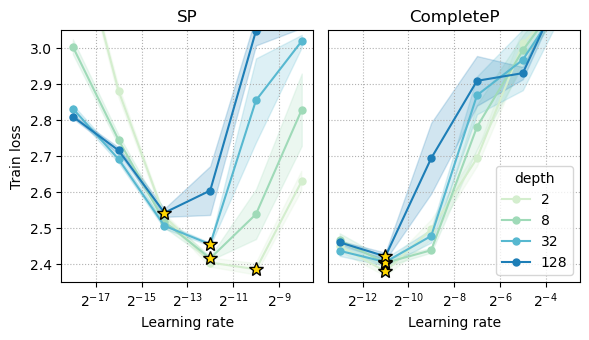

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

rootm = "/project/home/p200535/project/nanogpt-mup/shakespeare_char"
inits = [
    ('sp_depth', r'SP'),
    ('completep', r'CompleteP'),
]
seeds = [1, 2, 3]
width = 256
depths = [
    2,
    8,
    32,
    128
]
lrs = [
    0.125,
    0.0625,
    0.03125,
    0.015625,
    0.0078125,
    0.00390625,
    0.001953125,
    0.0009765625,
    0.00048828125,
    0.000244140625,
    0.0001220703125,
    0.00006103515625,
    0.00003051757812,
    0.00001525878906,
    0.000007629394531,
    0.000003814697266,
]

cmap = plt.get_cmap("GnBu", len(depths) + 2)
n_cols = len(inits)
n_rows = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3.5*n_rows))

for init_idx, (init, init_str) in enumerate(inits):
    ax = axes[init_idx]
    optimal_lrs = []
    optimal_losses = []
    for depth_idx, depth in enumerate(depths):
        mean_losses = []
        sem_losses = []
        lrs_to_plot = []
        for lr in lrs:
            losses = []
            for seed in seeds:
                job_name = f'width{width}_depth{depth}_seed{seed}_lr{lr:.20f}'.rstrip('0')
                csv_path = os.path.join(rootm, init, job_name, 'log.csv')
                if os.path.exists(csv_path):
                    ckpt_df = pd.read_csv(csv_path)
                    losses.append(ckpt_df['train/loss'].min())
                    # losses.append(ckpt_df['train/loss'].values[-1])
                # else:
                #     print(f'Missing {csv_path}')
            if len(losses):
                mean_losses.append(np.mean(losses))
                sem_losses.append(np.std(losses, ddof=1) / np.sqrt(len(losses)))
                lrs_to_plot.append(lr)
        
        mean_losses = np.array(mean_losses)
        sem_losses = np.array(sem_losses)
        ax.plot(lrs_to_plot, mean_losses, label=depth, marker='o', markersize=5, color=cmap(depth_idx+1))
        ax.fill_between(lrs_to_plot, mean_losses-sem_losses, mean_losses+sem_losses, color=cmap(depth_idx+1), alpha=0.2)
            
        if len(mean_losses):
            optimum_idx = np.argmin(mean_losses)
            optimal_lrs.append(lrs_to_plot[optimum_idx])
            optimal_losses.append(mean_losses[optimum_idx])
        
    ax.plot(optimal_lrs, optimal_losses, color='gold', markeredgecolor="black", markersize=10, linestyle='none', marker='*')
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Learning rate')
    ax.set_title(init_str)
    ax.set_ylim(2.35, 3.05)
    ax.grid(True, linestyle="dotted")

axes[1].legend(title='depth', loc='lower right')
axes[0].set_ylabel('Train loss')
axes[1].yaxis.set_ticklabels([])
axes[1].tick_params(axis='y', length=0, width=0)
plt.tight_layout()

### Plot merging

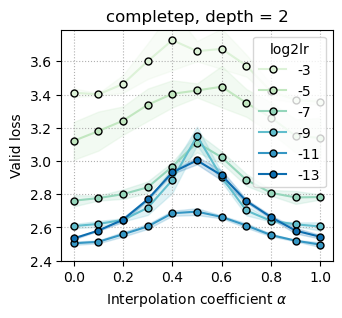

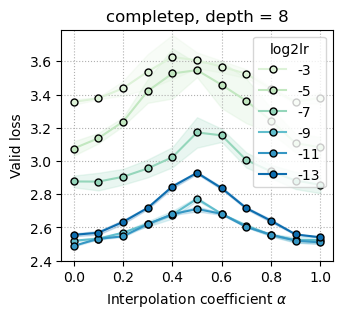

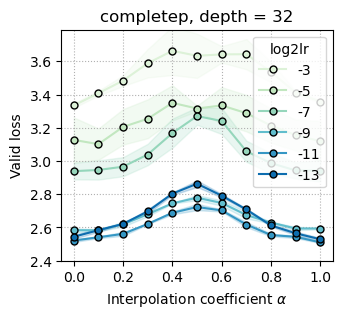

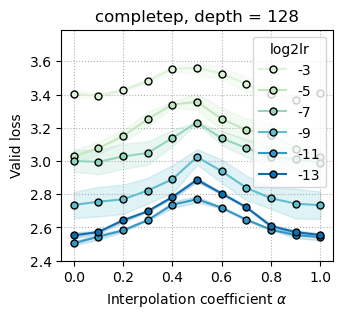

In [2]:
import json
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

init = "completep"
root = "/mnt/tier2/users/u102495/projects/nanogpt-mup/examples_completep/coord_check_shakespeare_char"
with open(f"{root}/results/merge_{init}.json", "r") as f:
    summary = json.load(f)
    
if init == "completep":
    lrs = [
        0.125,
        0.03125,
        0.0078125,
        0.001953125,
        0.00048828125,
        0.0001220703125,
    ]
elif init == "sp_depth":
    lrs = [
        0.00390625,
        0.0009765625,
        0.000244140625,
        0.00006103515625,
        0.00001525878906,
        0.000003814697266
    ]
else:
    raise ValueError

widths = [128, 512, 2048, 8192]
depths = [2, 8, 32, 128]
metric = "vl_loss"
ylabel = {
    "vl_loss": "Valid loss",
    "tr_loss": "Train loss",
}
seeds = [1, 2, 3]

init = init.split("_")[0]
for depth in depths:
    _, axs = plt.subplots(1, 1, figsize=(3.5, 3.0))
    cmap = plt.get_cmap("GnBu", len(lrs) + 2)

    x = np.linspace(0, 1, 9 + 2)
    for i, lr in enumerate(lrs):
        v = [summary[str(s)][str(lr)][str(depth)][metric] for s in seeds]
        y = np.mean(v, axis=0)
        yerr = np.std(v, axis=0, ddof=1) / np.sqrt(len(v)) 

        lr = str(int(np.log2(lr)))
        axs.plot(
            x,
            y,
            "-",
            marker="o",
            markeredgecolor="black",
            markersize=5,
            color=cmap(i + 1),
            label=lr,
        )
        axs.fill_between(
            x,
            y - yerr,
            y + yerr,
            color=cmap(i + 1),
            alpha=0.2,
        )

    axs.set_title(f"{init}, depth = {depth}")
    axs.set_xlabel(r"Interpolation coefficient $\alpha$")
    axs.set_ylabel(ylabel[metric])
    axs.grid(True, linestyle="dotted")
    axs.legend(title="log2lr", loc="upper right")

    if init == "sp":
        axs.set_ylim(2.40, 3.79)
    elif init == "completep":
        axs.set_ylim(2.40, 3.79)

    plt.savefig(
        f"{root}/figures/{metric}/merge_{init}_depth{depth}.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
    )

### Plot coordinate check

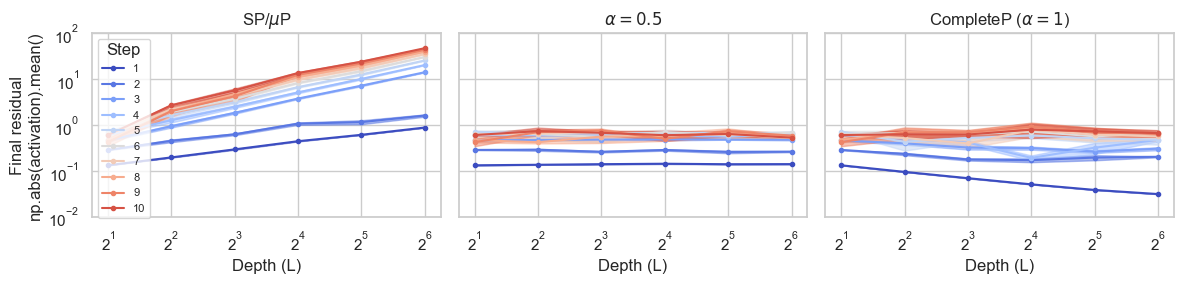

In [18]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import seaborn as sns
sns.set(style='whitegrid')

df_dict = {} # {parameterization: {job_name: df}}
for parameterization in os.listdir():
    df_dict[parameterization] = {}
    if parameterization == 'plot.ipynb':
        continue
    for job_name in os.listdir(os.path.join(parameterization, 'out')):
        df_dict[parameterization][job_name] = pd.read_csv(os.path.join(parameterization, 'out', job_name, 'log.csv'))

class MplColorHelper:

    def __init__(self, cmap_name, start_val, stop_val):
        self.cmap_name = cmap_name
        self.cmap = plt.get_cmap(cmap_name)
        self.norm = mpl.colors.Normalize(vmin=start_val, vmax=stop_val)
        self.scalarMap = cm.ScalarMappable(norm=self.norm, cmap=self.cmap)

    def get_rgb(self, val):
        return self.scalarMap.to_rgba(val)

layer_types = [
    # ('token_embedding_act_abs_mean', 'Word Embedding', (1.5e-2, 3.5e-2)),
    # ('attn_act_abs_mean', 'Attention Output', (1e-2, 1e4)),
    # ('mlp_act_abs_mean', 'FFN Output', (1e-2, 1e4)),
    ('last_layer_act_abs_mean', 'Final Residual Stream', (1e-2, 1e2)),
    # ('lm_head_act_abs_mean', 'Output Logits', (5e-2, 1e2)),
]
parameterizations = [
    ('sp_and_mup', r'SP/$\mu$P'),
    ('depth_alpha_05', r'$\alpha=0.5$'),
    ('depth_alpha_1_aka_completep', r'CompleteP ($\alpha=1$)'),
]
seeds = [1,2,3]
depths = [2,4,8,16,32,64]
# t_max = 1
# t_max = 2
t_max = 10

color_helper = MplColorHelper('coolwarm', 0, t_max)
n_cols = len(parameterizations)
n_rows = len(layer_types)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = np.array(axes).reshape((n_rows, n_cols))

for parameterization_idx, (parameterization, parameterization_str) in enumerate(parameterizations):
    results_matrix = np.zeros((len(layer_types), t_max, len(depths), len(seeds))) # (layer_type, t, width, seed)
    for depth_idx, depth in enumerate(depths):
        for seed_idx, seed in enumerate(seeds):
            depth_str = float(depth) if depth != 0 else int(depth)
            job_name = f'depth{depth}_width256_seed{seed}'
            try:
                ckpt_df = df_dict[parameterization][job_name]
            except:
                print(parameterization, job_name)
            if len(ckpt_df) == 0 or ckpt_df['step'].max() == 0:
                print(job_name)
                continue
            for layer_type_idx, (layer_type, layer_type_str, ylims) in enumerate(layer_types):
                results_matrix[layer_type_idx, :, depth_idx, seed_idx] = ckpt_df[layer_type].dropna().values[:t_max].flatten()

    for layer_type_idx, (layer_type, layer_type_str, ylims) in enumerate(layer_types):
        ax = axes[layer_type_idx, parameterization_idx]
        for t in range(0,t_max):
            means = []
            stderrs = []
            for depth_idx, depth in enumerate(depths):
                nnz_results = results_matrix[layer_type_idx, t, depth_idx][results_matrix[layer_type_idx, t, depth_idx] != 0]
                means.append(nnz_results.mean())
                stderrs.append(np.std(nnz_results, ddof=1) / np.sqrt(len(nnz_results)))
            means = np.array(means)
            stderrs = np.array(stderrs)
            ax.plot(depths, means, label=f'{t+1}', color=color_helper.get_rgb(t), marker='.')
            ax.fill_between(depths, means-stderrs, means+stderrs, color=color_helper.get_rgb(t), alpha=0.5)

        ax.set_title(parameterization_str)
        ax.set_xlabel('Depth (L)')
        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        ax.set_ylim(*ylims)
        if parameterization_idx > 0:
            ax.yaxis.set_ticklabels([])

axes[0, 0].set_ylabel('Final residual\nnp.abs(activation).mean()')
axes[0, 0].legend(loc='upper left', fontsize=8, title='Step')

plt.tight_layout()
plt.show()
plt.close()